# TMDB Veri Tabanı Genel İstatistikler ve Detaylı Analizler

Bu notebook'ta, TMDB veri tabanında bulunan veriler kullanılarak detaylı istatistiksel analizler yapılmaktadır. Kapsanan konular:
1. **Yönetmen Analizi:** En yüksek hasılat yapan yönetmenler.
2. **Oyuncu Analizi:** En çok hasılat yapan oyuncular.
3. **Yıllık Trend Analizi:** Yıllara göre film sayısı ve hasılat.
4. **Mevsimsellik:** Aylara göre ortalama hasılatlar.
5. **Korelasyon Analizi:** Filmin çeşitli özellikleri arasındaki ilişki.
6. **Süre ve Başarı İlişkisi:** Film süresi ve puan arasındaki bağlantı.
7. **Prodüksiyon Şirketleri:** En karlı prodüksiyon şirketleri.

In [2]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Uyarıları kapatma (Opsiyonel)
import warnings
warnings.filterwarnings('ignore')

# Klasörlerin oluşturulması
os.makedirs('grafikler', exist_ok=True)
os.makedirs('sonuclar', exist_ok=True)

# 1. Bağlantı Ayarları
server = r'.\SQLEXPRESS'
database = 'TMDB_MovieDB'
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    # 2. Veri Tabanına Bağlan
    conn = pyodbc.connect(conn_str)
    print("Veri Tabanına Başarıyla Bağlanıldı!")
except Exception as e:
    print(f"Bağlantı Hatası: {e}")

Veri Tabanına Başarıyla Bağlanıldı!


In [3]:
sonuclar_path = 'sonuclar/analiz_sonucu.txt'

def append_to_results(text):
    with open(sonuclar_path, 'a', encoding='utf-8') as f:
        f.write(text + '\n')

append_to_results("\n\n=== GENEL İSTATİSTİKLER VE DETAYLI ANALİZLER ===\n")

### 1. En Yüksek Toplam Hasılat Yapan 10 Yönetmen

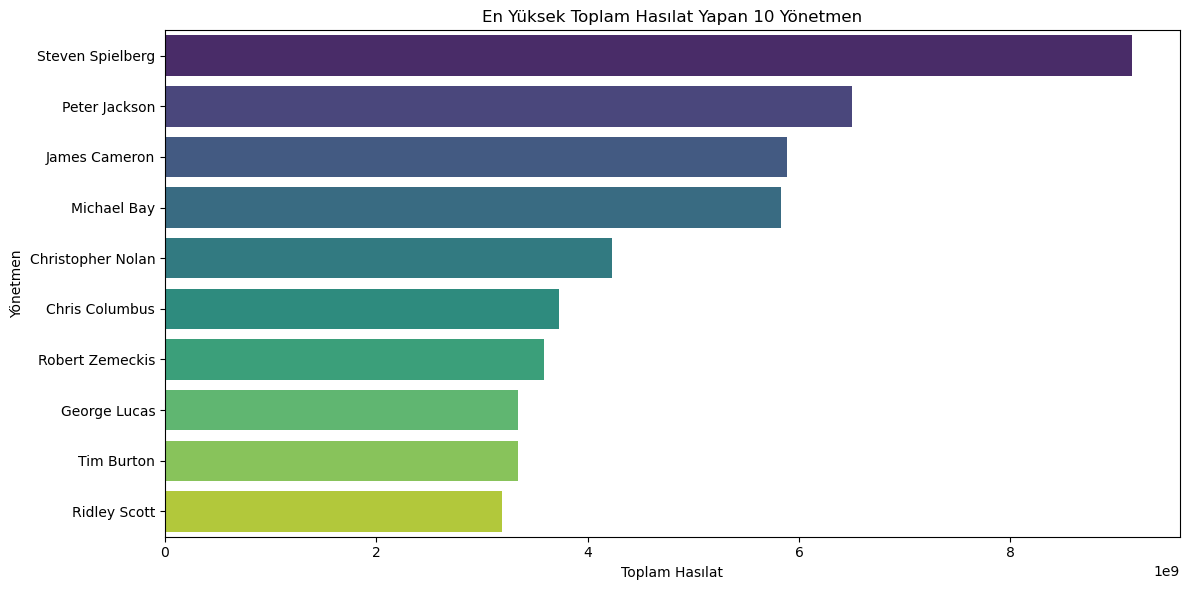

In [4]:
query_director = """
SELECT TOP 10 p.name as Director, SUM(m.revenue) as Total_Revenue, AVG(m.vote_average) as Avg_Vote, COUNT(m.movie_id) as Movie_Count
FROM Movies m
JOIN Crew c ON m.movie_id = c.movie_id
JOIN Persons p ON c.person_id = p.person_id
WHERE c.job = 'Director' AND m.revenue > 0
GROUP BY p.name
ORDER BY Total_Revenue DESC
"""
df_director = pd.read_sql(query_director, conn)

plt.figure(figsize=(12, 6))
sns.barplot(x='Total_Revenue', y='Director', data=df_director, palette='viridis')
plt.title('En Yüksek Toplam Hasılat Yapan 10 Yönetmen')
plt.xlabel('Toplam Hasılat')
plt.ylabel('Yönetmen')
plt.tight_layout()
plt.savefig('grafikler/yonetmen_hasilat_top10.png')
plt.show()

append_to_results(f"En çok hasılat yapan yönetmen: {df_director.iloc[0]['Director']} - Toplam Hasılat: {df_director.iloc[0]['Total_Revenue']}")

### 2. En Başarılı 10 Oyuncu (Hasılat)

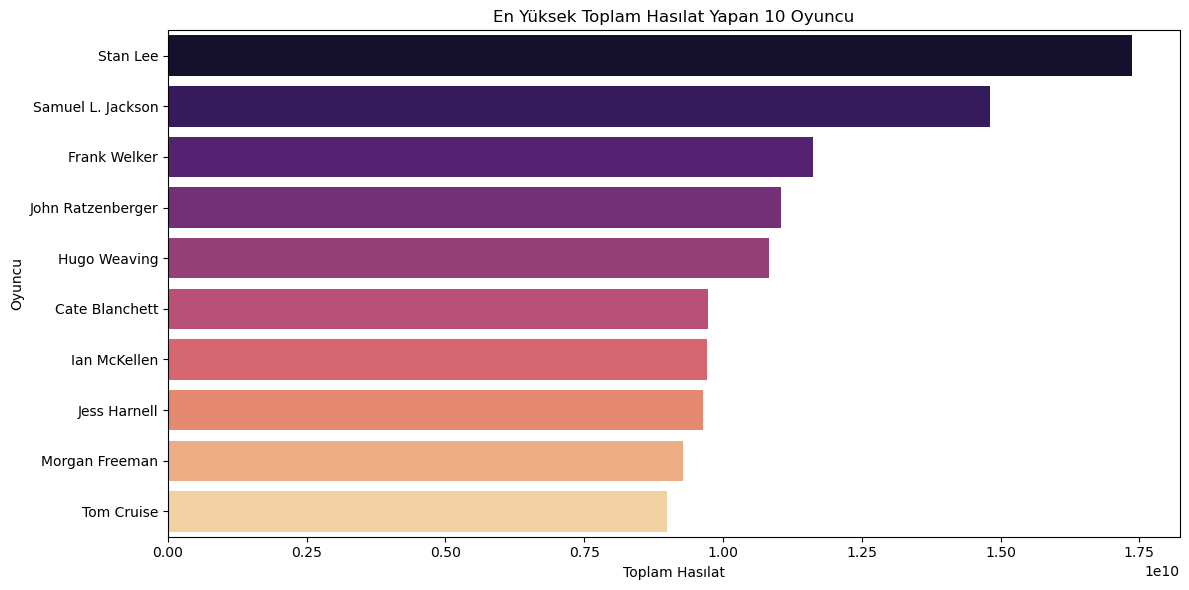

In [5]:
query_actor = """
SELECT TOP 10 p.name as Actor, SUM(m.revenue) as Total_Revenue, AVG(m.vote_average) as Avg_Vote, COUNT(m.movie_id) as Movie_Count
FROM Movies m
JOIN Cast c ON m.movie_id = c.movie_id
JOIN Persons p ON c.person_id = p.person_id
WHERE m.revenue > 0
GROUP BY p.name
ORDER BY Total_Revenue DESC
"""
df_actor = pd.read_sql(query_actor, conn)

plt.figure(figsize=(12, 6))
sns.barplot(x='Total_Revenue', y='Actor', data=df_actor, palette='magma')
plt.title('En Yüksek Toplam Hasılat Yapan 10 Oyuncu')
plt.xlabel('Toplam Hasılat')
plt.ylabel('Oyuncu')
plt.tight_layout()
plt.savefig('grafikler/oyuncu_hasilat_top10.png')
plt.show()

append_to_results(f"En çok hasılat yapan oyuncu: {df_actor.iloc[0]['Actor']} - Toplam Hasılat: {df_actor.iloc[0]['Total_Revenue']}")

### 3. Yıllık Trend Analizi (Hasılat ve Film Sayısı)

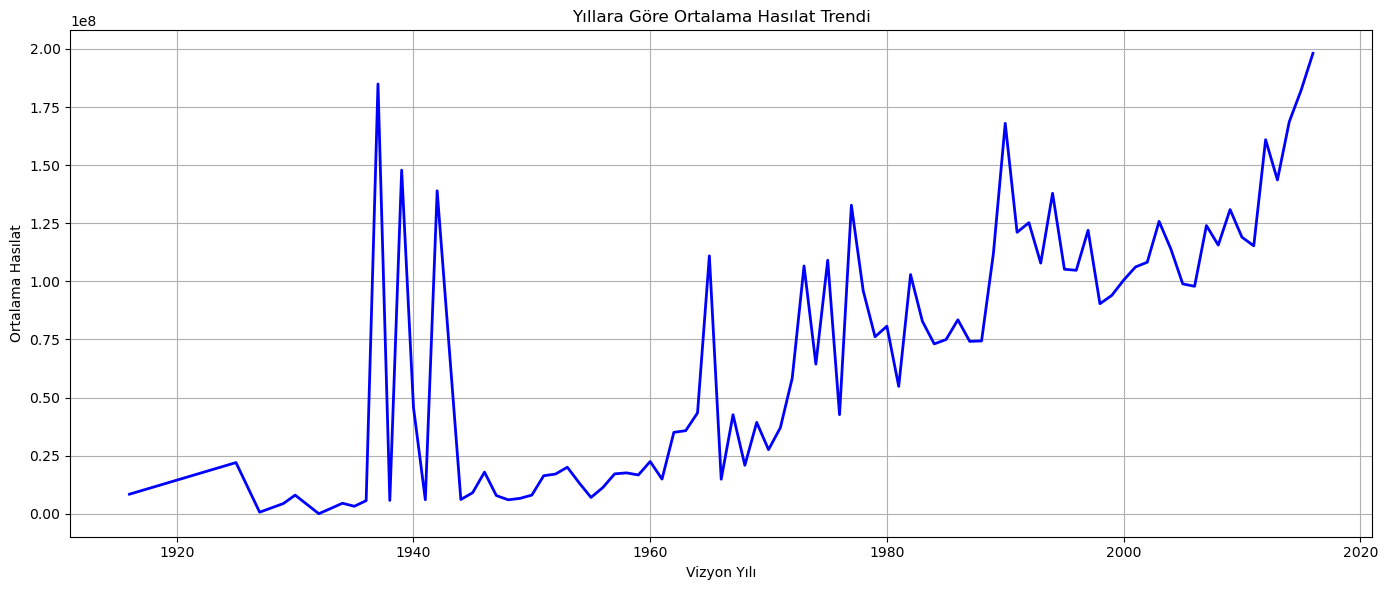

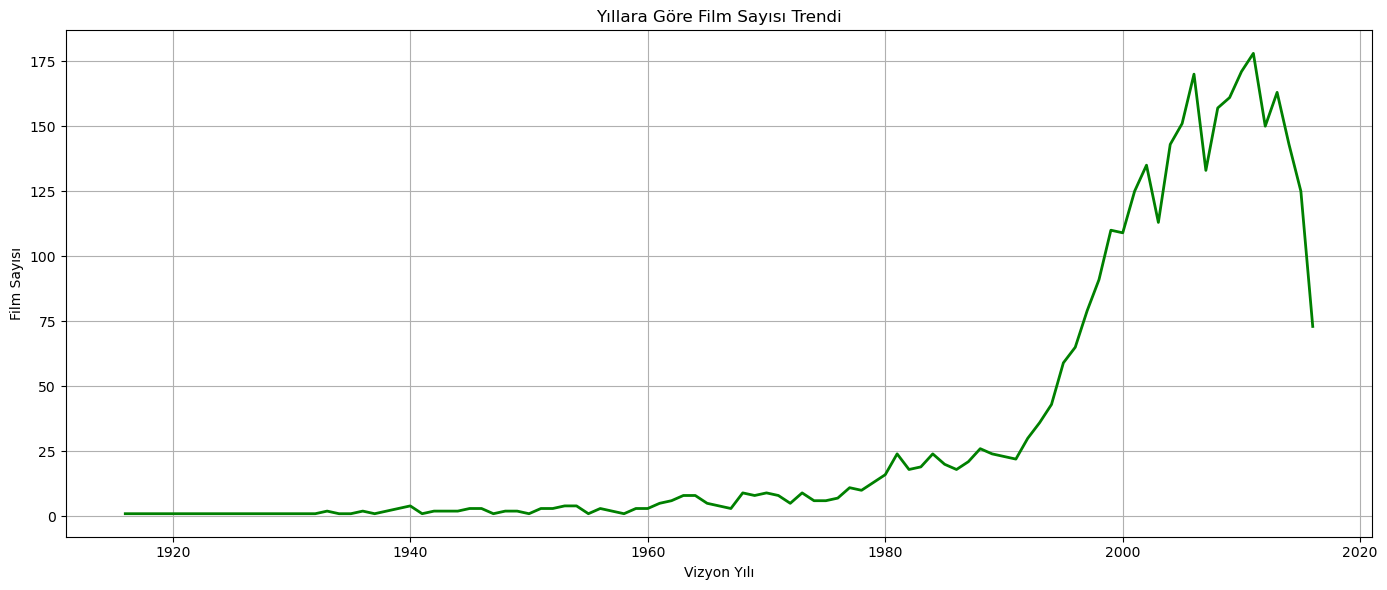

In [6]:
query_year = """
SELECT YEAR(release_date) as Release_Year, AVG(revenue) as Avg_Revenue, AVG(vote_average) as Avg_Vote, COUNT(movie_id) as Movie_Count
FROM Movies
WHERE release_date IS NOT NULL AND revenue > 0 AND vote_average > 0
GROUP BY YEAR(release_date)
HAVING YEAR(release_date) <= YEAR(GETDATE())
ORDER BY Release_Year
"""
df_year = pd.read_sql(query_year, conn)

plt.figure(figsize=(14, 6))
sns.lineplot(x='Release_Year', y='Avg_Revenue', data=df_year, color='b', linewidth=2)
plt.title('Yıllara Göre Ortalama Hasılat Trendi')
plt.xlabel('Vizyon Yılı')
plt.ylabel('Ortalama Hasılat')
plt.grid(True)
plt.tight_layout()
plt.savefig('grafikler/yillik_hasilat_trendi.png')
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(x='Release_Year', y='Movie_Count', data=df_year, color='g', linewidth=2)
plt.title('Yıllara Göre Film Sayısı Trendi')
plt.xlabel('Vizyon Yılı')
plt.ylabel('Film Sayısı')
plt.grid(True)
plt.tight_layout()
plt.savefig('grafikler/yillik_film_sayisi_trendi.png')
plt.show()

append_to_results("Yıllık trend analizleri (Ortalama Hasılat ve Film Sayısı) grafikleri kaydedildi.")

### 4. Mevsimsellik (Aylık Analiz)

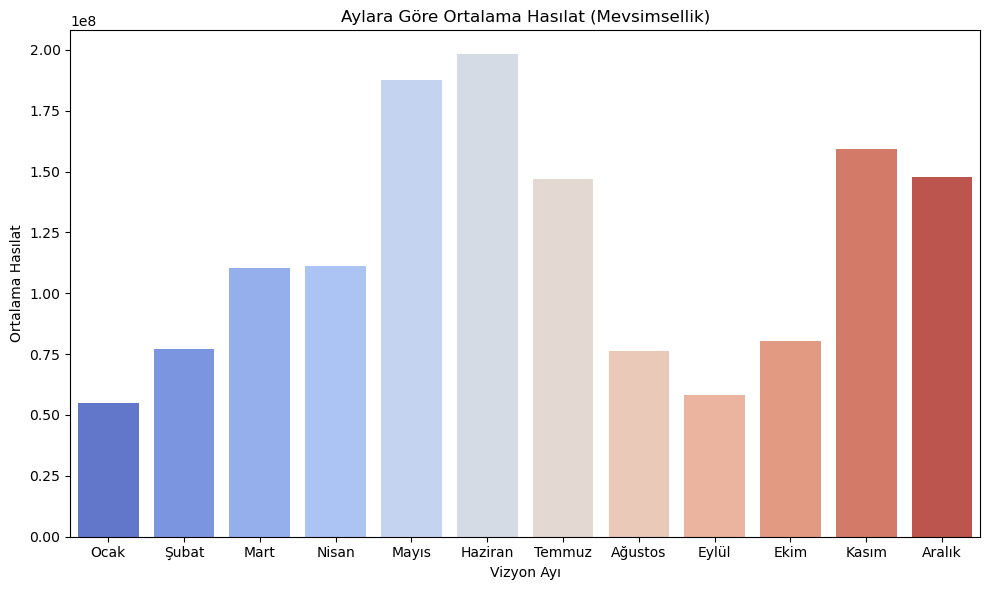

In [7]:
query_month = """
SELECT MONTH(release_date) as Release_Month, AVG(revenue) as Avg_Revenue, COUNT(movie_id) as Movie_Count
FROM Movies
WHERE release_date IS NOT NULL AND revenue > 0
GROUP BY MONTH(release_date)
ORDER BY Release_Month
"""
df_month = pd.read_sql(query_month, conn)

plt.figure(figsize=(10, 6))
sns.barplot(x='Release_Month', y='Avg_Revenue', data=df_month, palette='coolwarm')
plt.title('Aylara Göre Ortalama Hasılat (Mevsimsellik)')
plt.xlabel('Vizyon Ayı')
plt.ylabel('Ortalama Hasılat')
plt.xticks(range(12), ['Ocak', 'Şubat', 'Mart', 'Nisan', 'Mayıs', 'Haziran', 'Temmuz', 'Ağustos', 'Eylül', 'Ekim', 'Kasım', 'Aralık'])
plt.tight_layout()
plt.savefig('grafikler/aylik_hasilat_mevsimsellik.png')
plt.show()

en_karl_ay = df_month.loc[df_month['Avg_Revenue'].idxmax(), 'Release_Month']
aylar = ['Ocak', 'Şubat', 'Mart', 'Nisan', 'Mayıs', 'Haziran', 'Temmuz', 'Ağustos', 'Eylül', 'Ekim', 'Kasım', 'Aralık']
append_to_results(f"Ortalama olarak en çok hasılat getiren ay: {aylar[int(en_karl_ay)-1]}")

### 5. Metrikler Arası Korelasyon Analizi

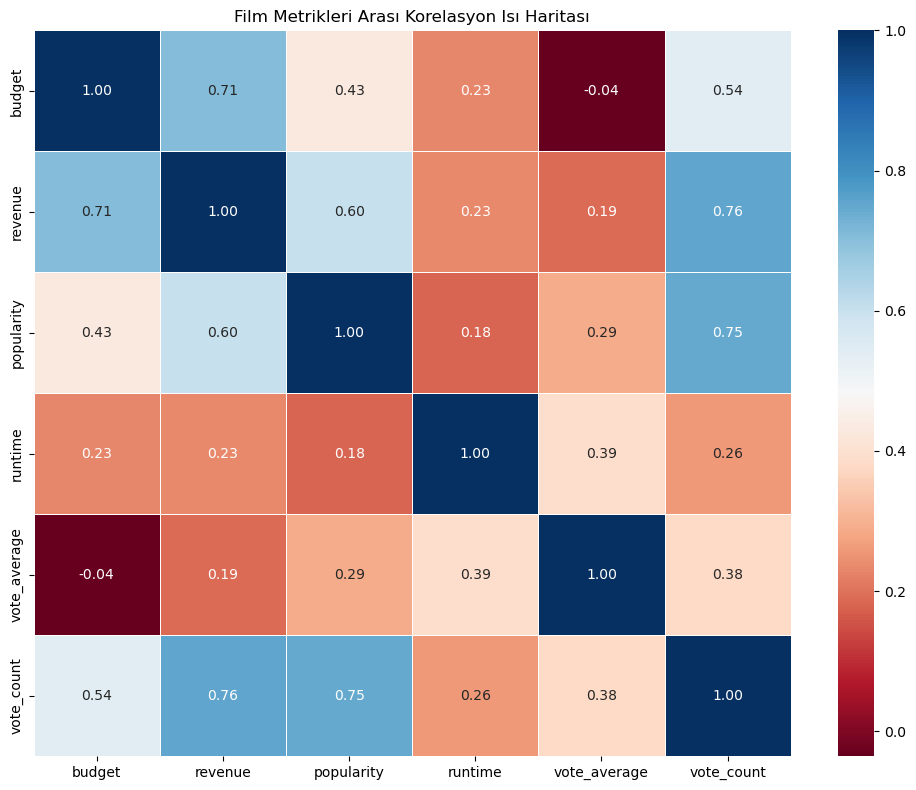

In [8]:
query_corr = """
SELECT budget, revenue, popularity, runtime, vote_average, vote_count
FROM Movies
WHERE budget > 0 AND revenue > 0 AND runtime > 0 AND vote_average > 0
"""
df_corr = pd.read_sql(query_corr, conn)
corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Film Metrikleri Arası Korelasyon Isı Haritası')
plt.tight_layout()
plt.savefig('grafikler/korelasyon_isi_haritasi.png')
plt.show()

append_to_results("Film metrikleri (Bütçe, Hasılat, Popülerlik, Süre, Puan, Oy) arasındaki korelasyon hesaplandı ve ısı haritası kaydedildi.")

### 6. Süre ve Başarı İlişkisi

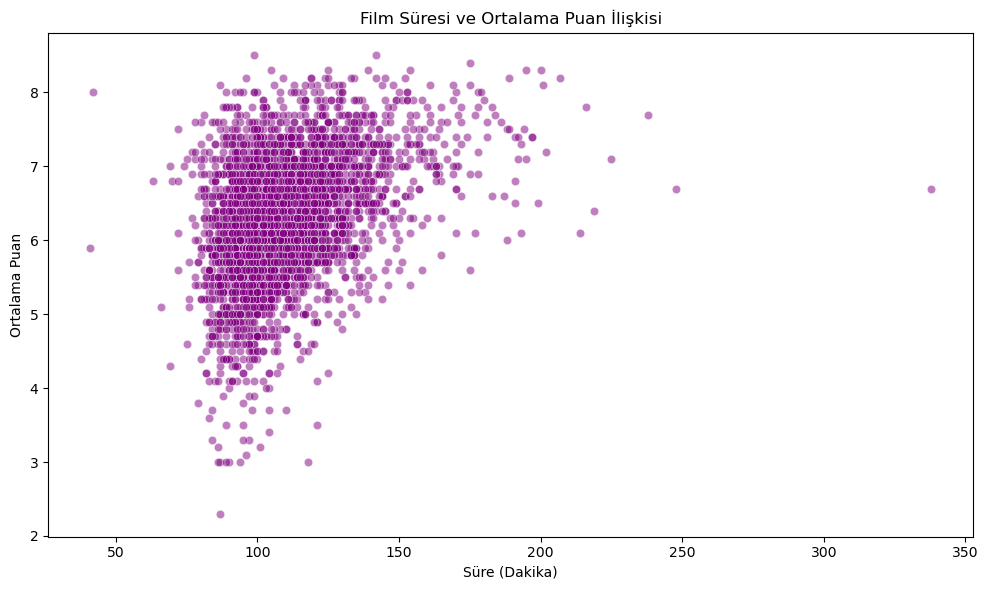

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='runtime', y='vote_average', data=df_corr, alpha=0.5, color='purple')
plt.title('Film Süresi ve Ortalama Puan İlişkisi')
plt.xlabel('Süre (Dakika)')
plt.ylabel('Ortalama Puan')
plt.tight_layout()
plt.savefig('grafikler/sure_puan_iliskisi.png')
plt.show()

append_to_results("Film süresi ve ortalama puan ilişkisini gösteren saçılım grafiği (scatter plot) kaydedildi.")

### 7. En Başarılı Prodüksiyon Şirketleri

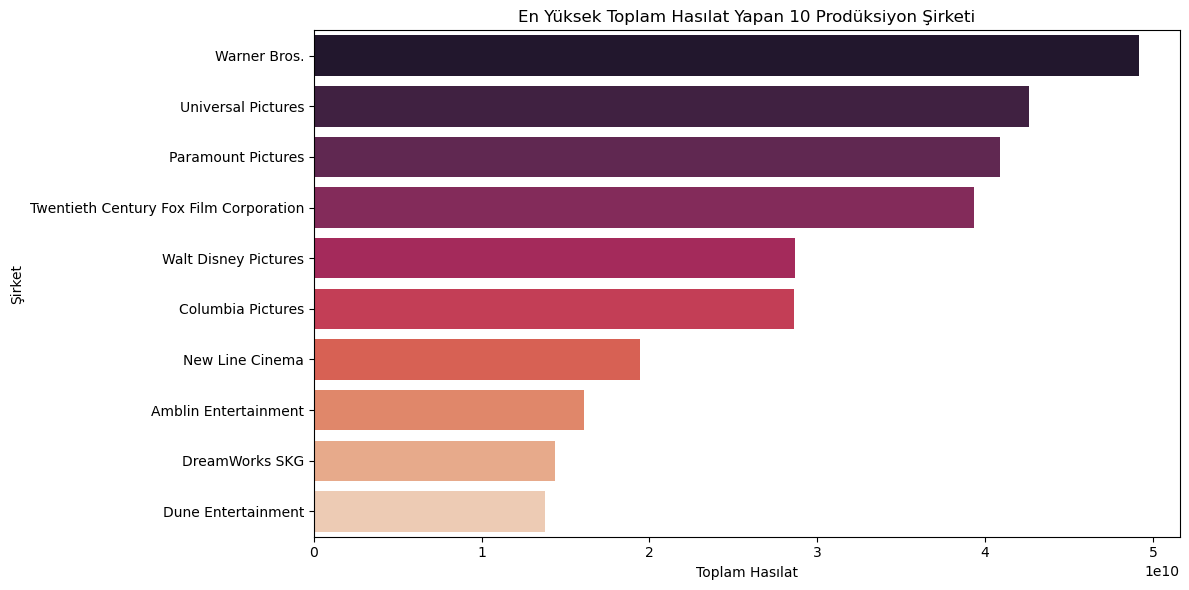

Tüm analizler başarıyla tamamlandı. Grafikler 'grafikler/' klasörüne kaydedildi ve sonuçlar 'sonuclar/analiz_sonucu.txt' dosyasına eklendi.


In [10]:
query_companies = """
SELECT TOP 10 pc.company_name as Company, COUNT(m.movie_id) as Movie_Count, AVG(m.revenue) as Avg_Revenue, SUM(m.revenue) as Total_Revenue
FROM Movies m
JOIN Movie_Production_Companies mpc ON m.movie_id = mpc.movie_id
JOIN Production_Companies pc ON mpc.company_id = pc.company_id
WHERE m.revenue > 0
GROUP BY pc.company_name
ORDER BY Total_Revenue DESC
"""
df_companies = pd.read_sql(query_companies, conn)

plt.figure(figsize=(12, 6))
sns.barplot(x='Total_Revenue', y='Company', data=df_companies, palette='rocket')
plt.title('En Yüksek Toplam Hasılat Yapan 10 Prodüksiyon Şirketi')
plt.xlabel('Toplam Hasılat')
plt.ylabel('Şirket')
plt.tight_layout()
plt.savefig('grafikler/sirket_hasilat_top10.png')
plt.show()

append_to_results(f"En çok hasılat elde eden prodüksiyon şirketi: {df_companies.iloc[0]['Company']} - Toplam Hasılat: {df_companies.iloc[0]['Total_Revenue']}")

print("Tüm analizler başarıyla tamamlandı. Grafikler 'grafikler/' klasörüne kaydedildi ve sonuçlar 'sonuclar/analiz_sonucu.txt' dosyasına eklendi.")

conn.close()